In [1]:
import yfinance as yf
import datetime
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf

import random

from tqdm import tqdm

/Users/hiroku007/miniforge3/envs/trailstone_assessment/lib/python3.8/site-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [2]:
def vwap(ticker):
    """
    calculates volume weighted average price of an asset at most recent tick.

    parameters:
        ticker: yfinance.Ticker object
    """
    bid_size, ask_size, ask_price, bid_price = ticker.info['bidSize'], ticker.info['askSize'], ticker.info['bid'], ticker.info['ask']

    return (bid_size * bid_price + ask_size * ask_price)/(bid_size + ask_size)

In [3]:
def simulate_outcomes(ticker, target_date, distribution, weights):
    """
    simulates the outcomes of a stock price by randomly drawing from the distribution of 2 minute returns between now and a target datetime object.
    currently, distribution is empirical, but advances could be made by implementing a (truncated) levy distro

    parameters:
        ticker: yfinance.Ticker object
        target_date: datetime object identifying the end time
        distribution: range of log returns to draw
        weights: probability of hitting a given bin_edge (the cdf)
    """

    #get time between
    current_date = datetime.datetime.now()
    time_delta = target_date - current_date

    intervals_to_expiry = time_delta.days * (15 + 6*30) + np.min([15 + 6*30, (time_delta.seconds//120)])
    print(intervals_to_expiry)
    log_returns_deviation = np.zeros(100000)

    
    for r in tqdm(range(len(log_returns_deviation))):
        for i in range(intervals_to_expiry):
            index_list = np.where(random.uniform(0,1)>weights)[0]
            if len(index_list)==0:
                index = 0
            else:
                index = np.max(index_list) + 1
            log_returns_deviation[r] += distribution[index]
    
    current_price = vwap(ticker)

    return np.exp(np.log(current_price) + log_returns_deviation)

In [4]:
spy = yf.Ticker('NVDA')


end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(59)


spy_hist = spy.history(interval = '2m', start = start_date ,end=end_date)

spy_hist = spy_hist.reset_index()

spy_hist['Date'] = spy_hist.apply(lambda row: row['Datetime'].date(), axis=1)
spy_hist['Time'] = spy_hist.apply(lambda row: row['Datetime'].time(), axis=1)


spy_hist['logClose'] = np.log(spy_hist['Close'])
spy_hist['logOpen'] = np.log(spy_hist['Open'])

spy_hist['logReturns'] = spy_hist['logClose'] - spy_hist['logOpen']

counts, bin_edges = np.histogram(spy_hist['logReturns'], bins=100)

In [1]:
plt.bar(bin_edges, counts)

NameError: name 'plt' is not defined

In [5]:
assumed_values = bin_edges[:100] + (np.diff(bin_edges))/2

assumed_increments = []
last_assumed_value = assumed_values[0]
for index, count in enumerate(counts):
    if count>0:
        assumed_increments.append((last_assumed_value + assumed_values[index])/2)
        last_assumed_value = assumed_values[index]

assumed_increments = np.asarray(assumed_increments)

In [6]:
cdf = np.cumsum(counts[counts!=0])/sum(counts[counts!=0])

In [7]:
cdf[assumed_increments>0]

array([0.6191557 , 0.71342109, 0.78347708, 0.84248752, 0.88440006,
       0.91345135, 0.93281888, 0.94916024, 0.96005447, 0.96943562,
       0.97548797, 0.98169163, 0.98517174, 0.98880315, 0.99077016,
       0.99258587, 0.99440157, 0.99530943, 0.99621728, 0.99667121,
       0.99727644, 0.99757906, 0.99773037, 0.99818429, 0.99878953,
       0.99894084, 0.99924346, 0.99939476, 0.99969738, 0.99984869,
       1.        ])

In [10]:
outcomes = simulate_outcomes(spy, datetime.datetime(2024,3,22,16,0,0), assumed_values, np.cumsum(counts)/np.sum(counts))

195


100%|█████████████████████████████████| 100000/100000 [00:57<00:00, 1743.76it/s]


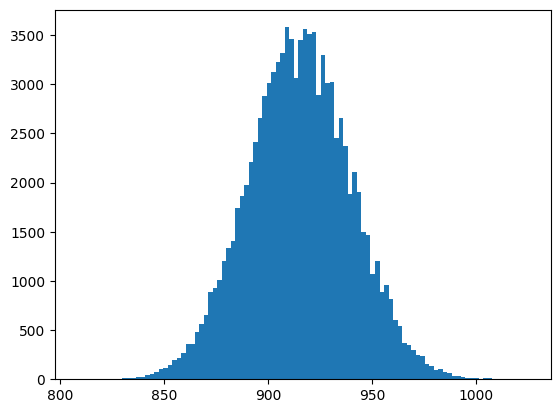

In [12]:
plt.hist(outcomes, bins=100)
plt.show()

In [14]:
vwap(spy)

914.3066666666666

In [16]:
mean_payout = 0
payouts = np.zeros(len(outcomes))
for index, elem in enumerate(outcomes):
    payouts[index] = ( - max(0, elem - 910) + max(0, elem - 905) - max(0, 915 - elem) + max(0, 920 - elem))
    
payouts.mean()

5.790191984121088

In [126]:
vwap(spy)

507.0444444444444